<a href="https://colab.research.google.com/github/limkc0116/FYP/blob/main/LIM%20KANG%20CHUN_yolov12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="vjuNLaTJfHC9loP7x85R")
project = rf.workspace("kangs-workspace-sc5tk").project("fyp-2-bglcr")
version = project.version(74)
dataset = version.download("yolov12")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 128.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to FYP-2-74 in yolov12:: 100%|██████████| 9361/9361 [00:01<00:00, 6719.57it/s]


In [ ]:
!nvidia-smi

Sun Jun  7 06:18:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 77.7 MB/s eta 0:00:00


In [ ]:
# Note: changed yolov12n.pt to yolo12n.pt
!yolo detect train data=/content/FYP-2-74/data.yaml model=yolo12n.pt epochs=100 batch=8 lr0=0.01

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/FYP-2-74/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, img

In [ ]:
from google.colab import drive
import shutil
import os

# 1. Mount Google Drive (if not already mounted)
drive.mount('/content/drive')

# 2. Define the paths
# Note: Double-check if your folder is 'train', 'train2', etc.
source_csv = '/content/runs/detect/train/results.csv'
destination_csv = '/content/drive/MyDrive/fyp1/finalyolov12_results.csv'

# 3. Copy the file
if os.path.exists(source_csv):
    shutil.copy(source_csv, destination_csv)
    print(f"Success! CSV saved to Drive as: {destination_csv}")
else:
    print(f"Error: Could not find the file at {source_csv}. Please check the folder path!")

Mounted at /content/drive
Success! CSV saved to Drive as: /content/drive/MyDrive/fyp1/finalyolov12_results.csv


In [ ]:
from google.colab import drive
import shutil
import os

drive.mount('/content/drive')

# Save weights
if os.path.exists('/content/runs/detect/train/weights/best.pt'):
    shutil.copy('/content/runs/detect/train/weights/best.pt', '/content/drive/MyDrive/fyp1/finalyolov12.pt')
    print("Weights saved!")

# Save CSV history
if os.path.exists('/content/runs/detect/train/results.csv'):
    shutil.copy('/content/runs/detect/train/results.csv', '/content/drive/MyDrive/fyp1/finalyolov12_results.csv')
    print("CSV history saved!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Weights saved!
CSV history saved!


In [ ]:
import cv2
import torch
import gc
from ultralytics import YOLO

# 1. Load Model
model = YOLO('/content/runs/detect/train/weights/best.pt')

# 2. Setup Paths
video_path = '/content/drive/MyDrive/fyp1/3_car.mp4'
output_path = '/content/drive/MyDrive/fyp1/finalcar3yolov12_Result.mp4'

cap = cv2.VideoCapture(video_path)
fps = int(cap.get(cv2.CAP_PROP_FPS))
w, h = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (w, h))

# 3. Prediction Settings
use_half = True if torch.cuda.is_available() else False

results = model.predict(
    source=video_path,
    half=use_half,
    stream=True,
    agnostic_nms=True,
    conf=0.5
)

# --- TRACKING VARIABLES ---
distraction_frames = 0
empty_frames_count = 0
grace_period_seconds = 0.5
grace_period_frames = int(grace_period_seconds * fps)

print(f"Processing... Video FPS: {fps} | Grace Period: {grace_period_frames} frames")

# 4. The Processing Loop
for r in results:
    annotated_frame = r.plot()

    if len(r.boxes) > 0:
        distraction_frames += 1
        empty_frames_count = 0
    else:
        empty_frames_count += 1

        if empty_frames_count > grace_period_frames:
            distraction_frames = 0
        else:
            if distraction_frames > 0:
                distraction_frames += 1

    # Calculate time based on accumulated frames
    elapsed_video_time = round(distraction_frames / fps, 1)

    # 5. Drawing Logic
    if distraction_frames > 0:
        timer_text = f"Timer: {elapsed_video_time}s"

        # --- TIMER TEXT (Black with White Outline for visibility) ---
        cv2.putText(annotated_frame, timer_text, (50, 150),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 4)
        cv2.putText(annotated_frame, timer_text, (50, 150),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)

        # --- REVISED 4-SECOND MULTI-STAGE ALERTS ---

        # Stage 2: CRITICAL ALERT (Triggered after 4.0 seconds total distraction)
        if elapsed_video_time >= 4.0:
            cv2.putText(annotated_frame, "!!! DISTRACTED ALERT !!!", (50, 100),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 255), 3) # RED

        # Stage 1: WARNING (Starts at 2.0 seconds, lasts for 2 seconds until 3.9s)
        elif elapsed_video_time >= 2.0:
            cv2.putText(annotated_frame, "WARNING: SAFETY LIMIT", (50, 100),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 255), 2) # YELLOW

    out.write(annotated_frame)

    # Memory Management
    del r
    gc.collect()

# 6. Cleanup
cap.release()
out.release()
print(f"✅ Processing Complete! Result saved to: {output_path}")

Streaming output truncated to the last 5000 lines.
video 1/1 (frame 6116/11113) /content/drive/MyDrive/fyp1/3_car.mp4: 384x640 (no detections), 22.0ms
video 1/1 (frame 6117/11113) /content/drive/MyDrive/fyp1/3_car.mp4: 384x640 (no detections), 20.3ms
video 1/1 (frame 6118/11113) /content/drive/MyDrive/fyp1/3_car.mp4: 384x640 (no detections), 24.3ms
video 1/1 (frame 6119/11113) /content/drive/MyDrive/fyp1/3_car.mp4: 384x640 (no detections), 22.7ms
video 1/1 (frame 6120/11113) /content/drive/MyDrive/fyp1/3_car.mp4: 384x640 (no detections), 21.7ms
video 1/1 (frame 6121/11113) /content/drive/MyDrive/fyp1/3_car.mp4: 384x640 (no detections), 21.1ms
video 1/1 (frame 6122/11113) /content/drive/MyDrive/fyp1/3_car.mp4: 384x640 (no detections), 22.7ms
video 1/1 (frame 6123/11113) /content/drive/MyDrive/fyp1/3_car.mp4: 384x640 (no detections), 22.9ms
video 1/1 (frame 6124/11113) /content/drive/MyDrive/fyp1/3_car.mp4: 384x640 (no detections), 23.6ms
video 1/1 (frame 6125/11113) /content/drive/MyDri

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12n summary (fused): 159 layers, 2,557,898 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1676.7±390.5 MB/s, size: 54.8 KB)
val: Scanning /content/FYP-2-74/valid/labels.cache... 550 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 550/550 153.8Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 372, len(boxes) = 550. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 3.9it/s 9.1s
                   all        550        550      0.983      0.991      0.992      0.872
        Center_Console        120        120      0.998          1      0.995      0.842
          Eat_or_Drink        119     

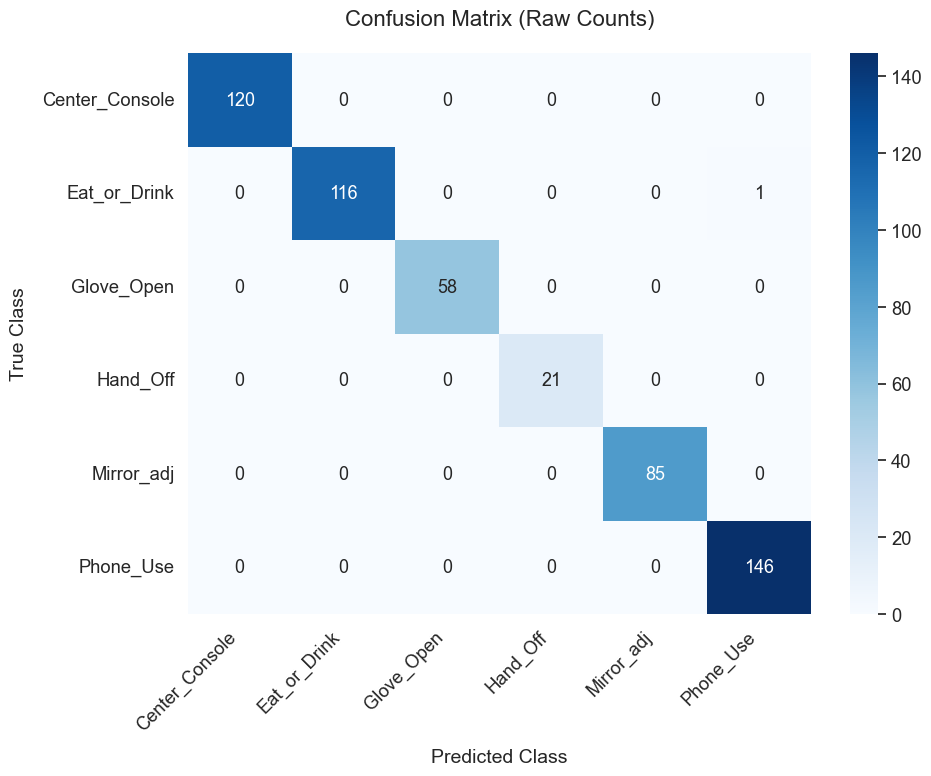

✅ Successfully plotted matrix with raw image counts: /content/drive/MyDrive/fyp1/confusion_matrix_raw_counts.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO

# 1. Load your trained model
model = YOLO('/content/runs/detect/train/weights/best.pt')

# 2. Run validation to get metrics
metrics = model.val(data='/content/FYP-2-74/data.yaml', split='val')

# 3. Get the raw internal confusion matrix array from Ultralytics
# Ultralytics stores this as a numpy array with background at the last row/col index
raw_matrix = metrics.confusion_matrix.matrix

# 4. Extract class names from model
class_names = list(model.names.values())
num_classes = len(class_names)

# 5. Crop the background row and column (keeping only your actual classes)
matrix_no_bg = raw_matrix[:num_classes, :num_classes].astype(int)

# 6. Plotting the Confusion Matrix with Raw Counts
plt.figure(figsize=(10, 8))
sns.set_theme(style="white", font_scale=1.2)

# Create the heatmap with raw integer counts explicitly shown
sns.heatmap(
    matrix_no_bg,
    annot=True,                                  # Enables display of numbers inside the boxes
    fmt="d",                                     # Forces numbers to display as integers (e.g., 120, 58)
    cmap="Blues",                                # Color gradient matching your image
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"size": 13, "fontweight": "bold"} # Keeps font bold and clear
)

plt.title('Confusion Matrix (Raw Counts)', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=14, labelpad=10)
plt.ylabel('True Class', fontsize=14, labelpad=10)
plt.xticks(rotation=45, ha='right')              # Rotates labels for neat layout
plt.yticks(rotation=0)
plt.tight_layout()

# 7. Save and Show the Result
output_img_path = '/content/drive/MyDrive/fyp1/confusion_matrix_raw_counts.png'
plt.savefig(output_img_path, dpi=300)
plt.show()

print(f"✅ Successfully plotted matrix with raw image counts: {output_img_path}")